In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import plotly.express as px
import matplotlib.pyplot as plt

# Read Data 

In [2]:
df=pd.read_csv('/Users/omartharwat/Desktop/Eplison/Final_project/cleaned_amazon_sales.csv')

In [3]:
df.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,ship-state,B2B,SKU_freq,year,month,day,Amount_missing,weekday,is_weekend,Amount_log
0,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389-KR-NP-S,Set,S,Unknown,0,...,MAHARASHTRA,False,36,2022,4,30,0,5,1,6.474847
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781-KR-XXXL,kurta,3XL,Shipped,1,...,KARNATAKA,False,108,2022,4,30,0,5,1,6.008813
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371-KR-XL,kurta,XL,Shipped,1,...,MAHARASHTRA,True,14,2022,4,30,0,5,1,5.799093
3,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341-DR-L,Western Dress,L,Unknown,0,...,PUDUCHERRY,False,270,2022,4,30,0,5,1,6.625830
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671-TU-XXXL,Top,3XL,Shipped,1,...,TAMIL NADU,False,17,2022,4,30,0,5,1,6.354370


# understand the Data


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126546 entries, 0 to 126545
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                126546 non-null  object 
 1   Status              126546 non-null  object 
 2   Fulfilment          126546 non-null  object 
 3   Sales Channel       126546 non-null  object 
 4   ship-service-level  126546 non-null  object 
 5   SKU                 126546 non-null  object 
 6   Category            126546 non-null  object 
 7   Size                126546 non-null  object 
 8   Courier Status      126546 non-null  object 
 9   Qty                 126546 non-null  int64  
 10  Amount              126546 non-null  float64
 11  ship-city           126513 non-null  object 
 12  ship-state          126513 non-null  object 
 13  B2B                 126546 non-null  bool   
 14  SKU_freq            126546 non-null  int64  
 15  year                126546 non-nul

In [5]:
df.describe(include='O')

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,ship-city,ship-state
count,126546,126546,126546,126546,126546,126546,126546,126546,126546,126513,126513
unique,91,13,2,2,2,7195,9,11,4,8955,69
top,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,JNE3797-KR-L,Set,M,Shipped,BENGALURU,MAHARASHTRA
freq,2028,76576,87864,126423,86782,713,49347,22227,108016,10666,21863


In [6]:
freq = df['SKU'].value_counts()

df['SKU_freq'] = df['SKU'].map(freq)
df['SKU_freq']

0          36
1         108
2          14
3         270
4          17
         ... 
126541     77
126542     26
126543     94
126544     42
126545    315
Name: SKU_freq, Length: 126546, dtype: int64

In [7]:
df["ship-city"] = df["ship-city"].fillna("Unknown")
top_cities = df["ship-city"].value_counts().nlargest(20).index
df["ship_city_grouped"] = df["ship-city"].where(df["ship-city"].isin(top_cities), "Other")
df["ship_city_grouped_freq"] = df["ship_city_grouped"].map(df["ship_city_grouped"].value_counts())

In [8]:
df.head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,SKU_freq,year,month,day,Amount_missing,weekday,is_weekend,Amount_log,ship_city_grouped,ship_city_grouped_freq
0,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389-KR-NP-S,Set,S,Unknown,0,...,36,2022,4,30,0,5,1,6.474847,MUMBAI,5952
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781-KR-XXXL,kurta,3XL,Shipped,1,...,108,2022,4,30,0,5,1,6.008813,BENGALURU,10666
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371-KR-XL,kurta,XL,Shipped,1,...,14,2022,4,30,0,5,1,5.799093,NAVI MUMBAI,1254
3,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341-DR-L,Western Dress,L,Unknown,0,...,270,2022,4,30,0,5,1,6.625830,Other,70164
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671-TU-XXXL,Top,3XL,Shipped,1,...,17,2022,4,30,0,5,1,6.354370,CHENNAI,5226


 # Cleaning and Drop columns

In [9]:
df.drop(['index','Order ID','Style','Unnamed: 22','promotion-ids','currency','ship-postal-code','ASIN','ship-country',],axis=1,inplace=True)

KeyError: "['index', 'Order ID', 'Style', 'Unnamed: 22', 'promotion-ids', 'currency', 'ship-postal-code', 'ASIN', 'ship-country'] not found in axis"

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126546 entries, 0 to 126545
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    126546 non-null  object 
 1   Status                  126546 non-null  object 
 2   Fulfilment              126546 non-null  object 
 3   Sales Channel           126546 non-null  object 
 4   ship-service-level      126546 non-null  object 
 5   SKU                     126546 non-null  object 
 6   Category                126546 non-null  object 
 7   Size                    126546 non-null  object 
 8   Courier Status          126546 non-null  object 
 9   Qty                     126546 non-null  int64  
 10  Amount                  126546 non-null  float64
 11  ship-city               126546 non-null  object 
 12  ship-state              126513 non-null  object 
 13  B2B                     126546 non-null  bool   
 14  SKU_freq            

 # Change the Date and Extract Year ,month and day

In [11]:
df['Date']=pd.to_datetime(df['Date'])

In [12]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekday"] = df["Date"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

In [13]:
df.isna().sum()

Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
SKU                        0
Category                   0
Size                       0
Courier Status             0
Qty                        0
Amount                     0
ship-city                  0
ship-state                33
B2B                        0
SKU_freq                   0
year                       0
month                      0
day                        0
Amount_missing             0
weekday                    0
is_weekend                 0
Amount_log                 0
ship_city_grouped          0
ship_city_grouped_freq     0
dtype: int64

In [14]:

df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126546 entries, 0 to 126545
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Date                    126546 non-null  datetime64[ns]
 1   Status                  126546 non-null  object        
 2   Fulfilment              126546 non-null  object        
 3   Sales Channel           126546 non-null  object        
 4   ship-service-level      126546 non-null  object        
 5   SKU                     126546 non-null  object        
 6   Category                126546 non-null  object        
 7   Size                    126546 non-null  object        
 8   Courier Status          126546 non-null  object        
 9   Qty                     126546 non-null  int64         
 10  Amount                  126546 non-null  float64       
 11  ship-city               126546 non-null  object        
 12  ship-state              126513

In [17]:
df['Courier Status'].value_counts()

Courier Status
Shipped      108016
Unknown        6531
Unshipped      6337
Cancelled      5662
Name: count, dtype: int64

In [18]:
df['Courier Status']= (df['Courier Status'].astype("string").
str.strip()
.fillna("Unknown"))

In [19]:
df['Courier Status'].value_counts()

Courier Status
Shipped      108016
Unknown        6531
Unshipped      6337
Cancelled      5662
Name: count, dtype: Int64

# Percentage of NUlls to take decsions of drop other columns or not ???


In [20]:
null_percent = df.isna().mean() * 100
null_percent


Date                      0.000000
Status                    0.000000
Fulfilment                0.000000
Sales Channel             0.000000
ship-service-level        0.000000
SKU                       0.000000
Category                  0.000000
Size                      0.000000
Courier Status            0.000000
Qty                       0.000000
Amount                    0.000000
ship-city                 0.000000
ship-state                0.026077
B2B                       0.000000
SKU_freq                  0.000000
year                      0.000000
month                     0.000000
day                       0.000000
Amount_missing            0.000000
weekday                   0.000000
is_weekend                0.000000
Amount_log                0.000000
ship_city_grouped         0.000000
ship_city_grouped_freq    0.000000
dtype: float64

<Axes: xlabel='Amount', ylabel='Count'>

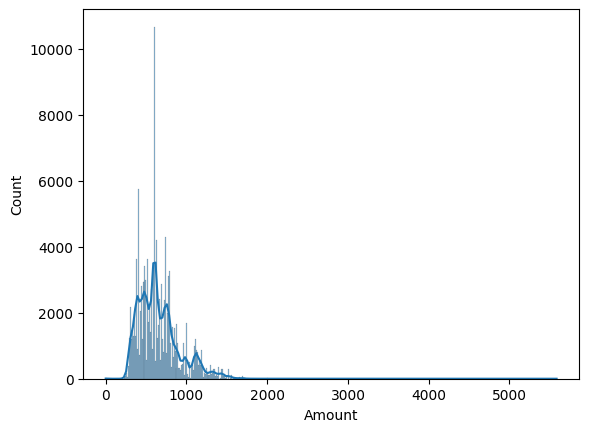

In [21]:
sns.histplot(df['Amount'], kde=True)

# handle Amount value duo to Right skwed using fill with median and after that use log


In [22]:
df['Amount']=df['Amount'].fillna(df['Amount'].median())

In [23]:
df.isna().sum()

Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
SKU                        0
Category                   0
Size                       0
Courier Status             0
Qty                        0
Amount                     0
ship-city                  0
ship-state                33
B2B                        0
SKU_freq                   0
year                       0
month                      0
day                        0
Amount_missing             0
weekday                    0
is_weekend                 0
Amount_log                 0
ship_city_grouped          0
ship_city_grouped_freq     0
dtype: int64

<Axes: xlabel='Amount', ylabel='Count'>

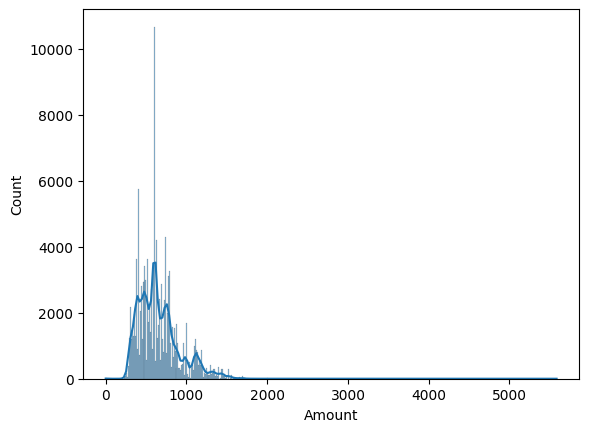

In [24]:
sns.histplot(df['Amount'], kde=True)

<Axes: xlabel='Amount_log', ylabel='Count'>

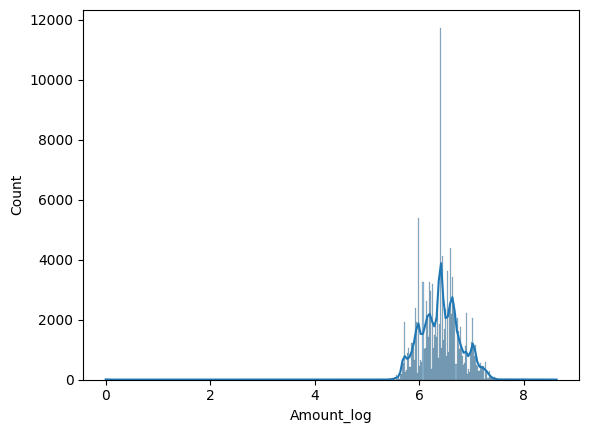

In [25]:
df["Amount_log"] = np.log1p(df["Amount"])
sns.histplot(df['Amount_log'], kde=True)

In [43]:
df['fulfilled-by'].value_counts()

KeyError: 'fulfilled-by'

In [26]:
df['fulfilled_by_flag'] = df['fulfilled-by'].notna().astype(int)

KeyError: 'fulfilled-by'

In [ ]:
df.groupby('fulfilled_by_flag')['Amount'].mean()

fulfilled_by_flag
0    646.296845
1    644.244348
Name: Amount, dtype: float64

In [ ]:
df.drop(columns=['fulfilled-by', 'fulfilled_by_flag'], inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126546 entries, 0 to 126545
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Date                    126546 non-null  datetime64[ns]
 1   Status                  126546 non-null  object        
 2   Fulfilment              126546 non-null  object        
 3   Sales Channel           126546 non-null  object        
 4   ship-service-level      126546 non-null  object        
 5   SKU                     126546 non-null  object        
 6   Category                126546 non-null  object        
 7   Size                    126546 non-null  object        
 8   Courier Status          126546 non-null  string        
 9   Qty                     126546 non-null  int64         
 10  Amount                  126546 non-null  float64       
 11  ship-city               126546 non-null  object        
 12  ship-state              126513

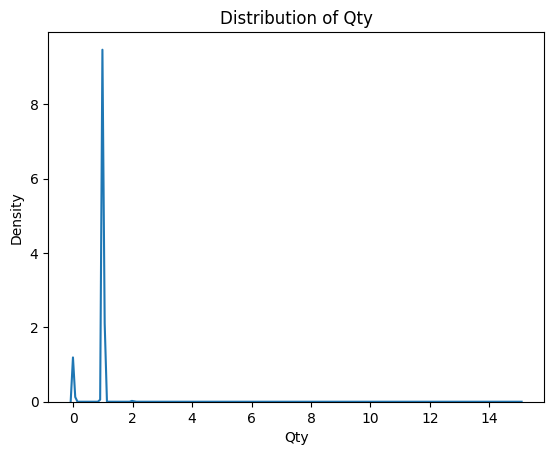

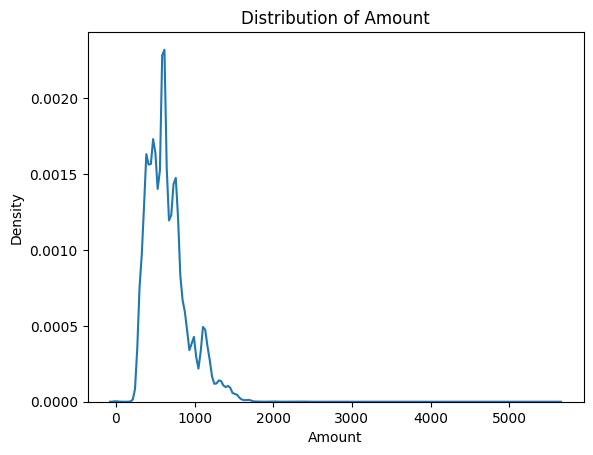

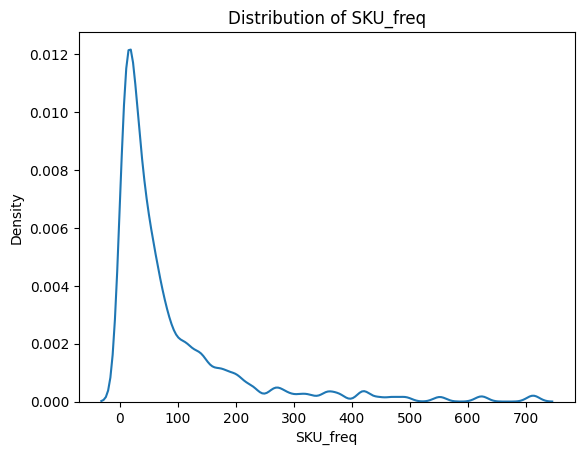

/var/folders/6v/7nf6d6j92ln3kkkd5wdv0bjr0000gn/T/ipykernel_13775/1238127582.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col)


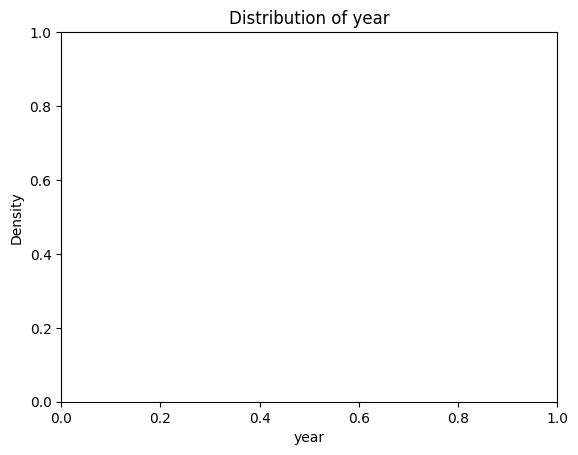

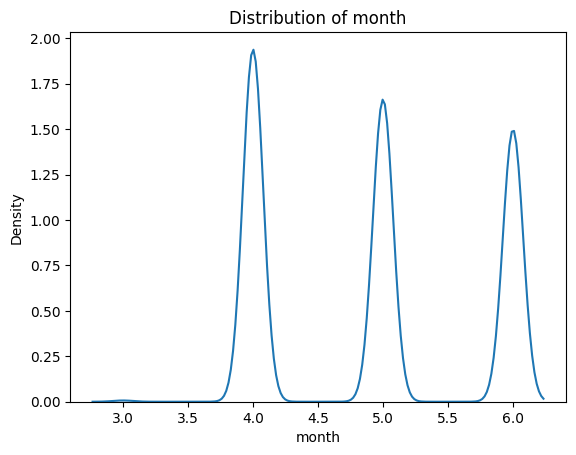

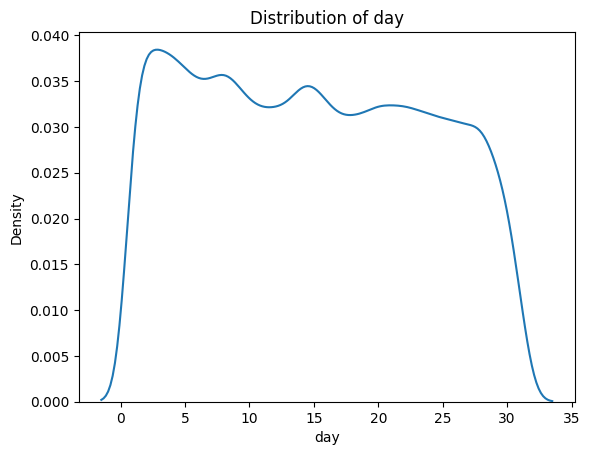

/var/folders/6v/7nf6d6j92ln3kkkd5wdv0bjr0000gn/T/ipykernel_13775/1238127582.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col)


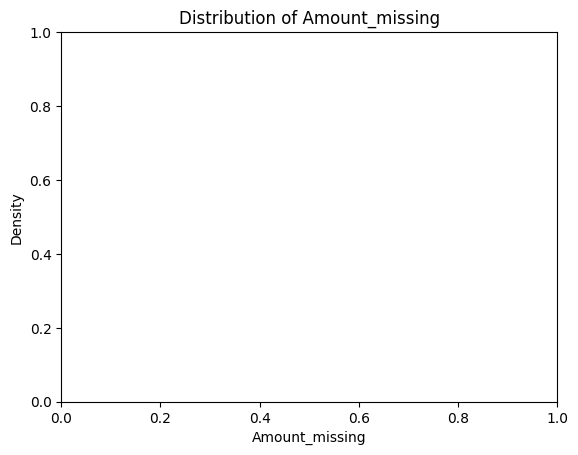

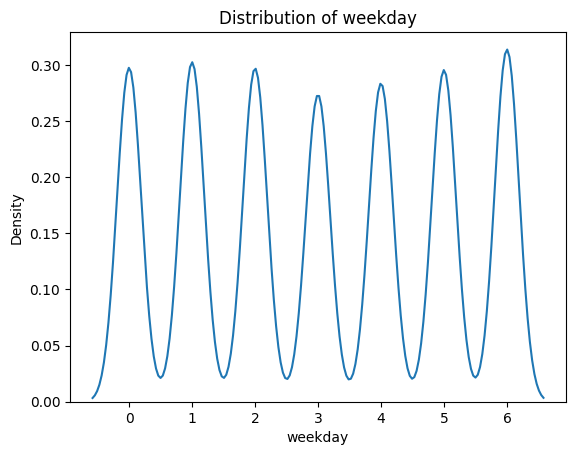

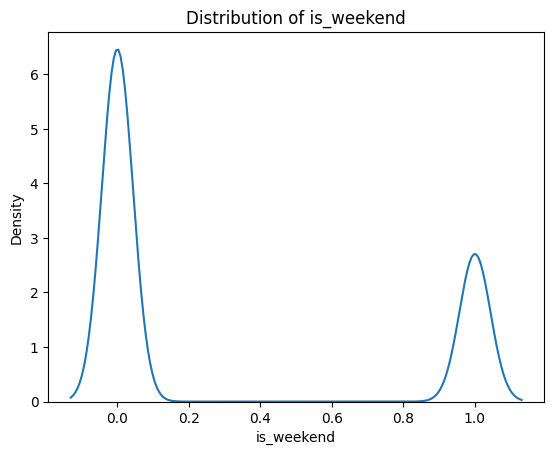

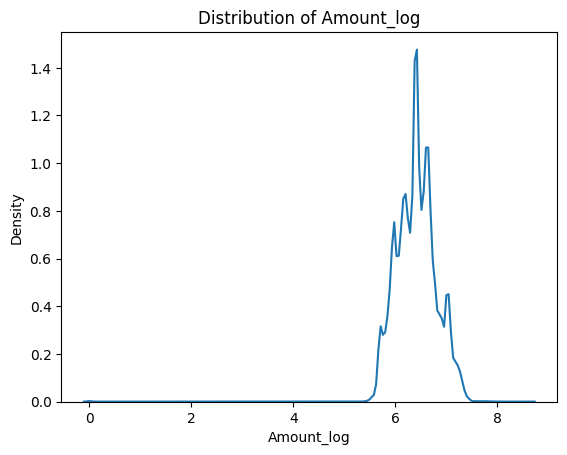

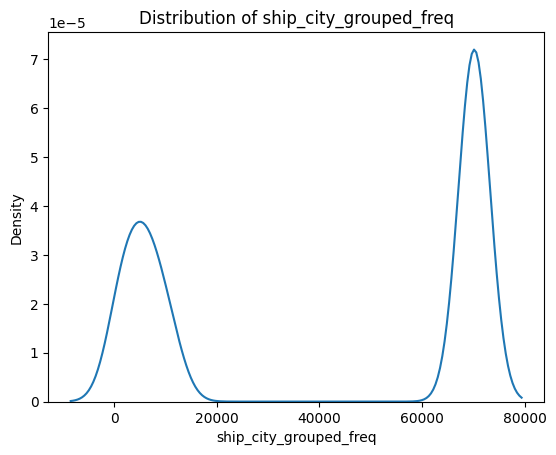

In [28]:
for col in df.select_dtypes('number').columns:
    plt.figure()
    sns.kdeplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

In [29]:
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')

In [30]:
df[df['Amount']==0]

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,SKU_freq,year,month,day,Amount_missing,weekday,is_weekend,Amount_log,ship_city_grouped,ship_city_grouped_freq
89349,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3797-KR-M,Western Dress,M,Unshipped,1,...,624,2022,6,29,0,2,0,0.0,Other,70164
89402,2022-06-29,Pending,Amazon,Amazon.in,Standard,JNE3781-KR-L,kurta,L,Unshipped,1,...,85,2022,6,29,0,2,0,0.0,Other,70164
89475,2022-06-29,Pending,Amazon,Amazon.in,Expedited,SET357-KR-NP-XXL,Set,XXL,Unshipped,1,...,40,2022,6,29,0,2,0,0.0,Other,70164
89562,2022-06-29,Pending,Amazon,Amazon.in,Expedited,JNE3690-TU-S,Top,S,Unshipped,1,...,38,2022,6,29,0,2,0,0.0,Other,70164
89576,2022-06-29,Pending,Merchant,Amazon.in,Standard,SET357-KR-NP-S,Set,S,Unshipped,1,...,58,2022,6,29,0,2,0,0.0,Other,70164
89581,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3811-KR-M,kurta,M,Unshipped,1,...,7,2022,6,29,0,2,0,0.0,Mumbai,859
89656,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3797-KR-A-XL,Western Dress,XL,Unshipped,1,...,65,2022,6,29,0,2,0,0.0,Other,70164
89737,2022-06-29,Pending,Merchant,Amazon.in,Standard,J0290-CD-XL,Top,XL,Unshipped,1,...,4,2022,6,29,0,2,0,0.0,Other,70164
89977,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3797-KR-L,Western Dress,L,Unshipped,1,...,713,2022,6,29,0,2,0,0.0,Other,70164
90073,2022-06-28,Pending,Amazon,Amazon.in,Expedited,J0370-SKD-XXL,Set,XXL,Unshipped,1,...,3,2022,6,28,0,1,0,0.0,BENGALURU,10666


In [31]:
df['Courier Status'].value_counts()

Courier Status
Shipped      108016
Unknown        6531
Unshipped      6337
Cancelled      5662
Name: count, dtype: Int64

In [32]:
df['Category'].value_counts()

Category
Set              49347
kurta            49013
Western Dress    15041
Top              10474
Ethnic Dress      1153
Blouse             914
Bottom             437
Saree              164
Dupatta              3
Name: count, dtype: int64

In [ ]:
df = df.drop(columns=['Amount_log'], errors='ignore')

In [ ]:
df[df['Courier Status']=='Cancelled']

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,B2B,SKU_freq,year,month,day
8,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,SET200-KR-NP-A-XXXL,Set,3XL,Cancelled,0,603.0,HYDERABAD,TELANGANA,False,17,2022,4,30
65,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3373-KR-XXL,kurta,XXL,Cancelled,0,603.0,Dahod,Gujarat,False,227,2022,4,30
84,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3510-KR-M,kurta,M,Cancelled,0,603.0,HYDERABAD,TELANGANA,False,128,2022,4,30
95,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,JNE3405-KR-L,kurta,L,Cancelled,0,603.0,PUNE,MAHARASHTRA,False,535,2022,4,30
101,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,SET347-KR-NP-S,Set,S,Cancelled,0,603.0,NEW DELHI,DELHI,False,59,2022,4,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128903,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,JNE3801-KR-M,kurta,M,Cancelled,0,603.0,ANANTAPUR,ANDHRA PRADESH,False,169,2022,5,31
128907,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,NW014-ST-SR-XXXL,Set,3XL,Cancelled,0,603.0,GREATER NOIDA,UTTAR PRADESH,False,16,2022,5,31
128908,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,NW007-ST-CP-XXXL,Set,3XL,Cancelled,0,603.0,GREATER NOIDA,UTTAR PRADESH,False,7,2022,5,31
128958,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,SET058-KR-NP-L,Set,L,Cancelled,0,603.0,Bengaluru,KARNATAKA,False,72,2022,5,31


In [33]:
df[
    (df['Amount'] == 0.0) &
    (df['Courier Status'] == 'Unshipped')
]

,Date,Status,Fulfilment,Sales Channel,ship-service-level,SKU,Category,Size,Courier Status,Qty,...,SKU_freq,year,month,day,Amount_missing,weekday,is_weekend,Amount_log,ship_city_grouped,ship_city_grouped_freq
89349,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3797-KR-M,Western Dress,M,Unshipped,1,...,624,2022,6,29,0,2,0,0.0,Other,70164
89402,2022-06-29,Pending,Amazon,Amazon.in,Standard,JNE3781-KR-L,kurta,L,Unshipped,1,...,85,2022,6,29,0,2,0,0.0,Other,70164
89475,2022-06-29,Pending,Amazon,Amazon.in,Expedited,SET357-KR-NP-XXL,Set,XXL,Unshipped,1,...,40,2022,6,29,0,2,0,0.0,Other,70164
89562,2022-06-29,Pending,Amazon,Amazon.in,Expedited,JNE3690-TU-S,Top,S,Unshipped,1,...,38,2022,6,29,0,2,0,0.0,Other,70164
89576,2022-06-29,Pending,Merchant,Amazon.in,Standard,SET357-KR-NP-S,Set,S,Unshipped,1,...,58,2022,6,29,0,2,0,0.0,Other,70164
89581,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3811-KR-M,kurta,M,Unshipped,1,...,7,2022,6,29,0,2,0,0.0,Mumbai,859
89656,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3797-KR-A-XL,Western Dress,XL,Unshipped,1,...,65,2022,6,29,0,2,0,0.0,Other,70164
89737,2022-06-29,Pending,Merchant,Amazon.in,Standard,J0290-CD-XL,Top,XL,Unshipped,1,...,4,2022,6,29,0,2,0,0.0,Other,70164
89977,2022-06-29,Pending,Merchant,Amazon.in,Standard,JNE3797-KR-L,Western Dress,L,Unshipped,1,...,713,2022,6,29,0,2,0,0.0,Other,70164
90073,2022-06-28,Pending,Amazon,Amazon.in,Expedited,J0370-SKD-XXL,Set,XXL,Unshipped,1,...,3,2022,6,28,0,1,0,0.0,BENGALURU,10666


In [34]:
df.loc[
    (df['Amount']==0) & (df['Courier Status']=='Shipped'),'Amount'
] = np.nan

In [35]:
df['Amount_missing'] = df['Amount'].isna().astype(int)

In [36]:
df['Amount'] = df['Amount'].fillna(df['Amount'].median())

<Axes: xlabel='Amount', ylabel='Density'>

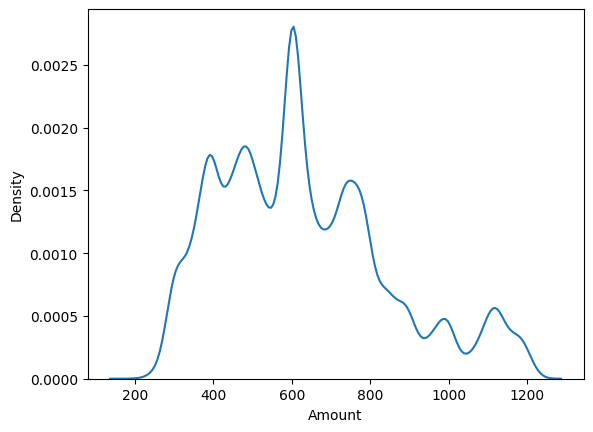

In [47]:
sns.kdeplot(df['Amount'])

# Handling Outliers 

In [38]:
Q1=df['Amount'].quantile(0.75)
Q3=df['Amount'].quantile(0.25)
IQR=Q1-Q3
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

318.0 922.0


In [39]:
outliers = df[df['Amount'] < upper]

outliers[['Amount', 'Category', 'Qty', 'Status']].head()

,Amount,Category,Qty,Status
0,647.62,Set,0,Cancelled
1,406.00,kurta,1,Shipped - Delivered to Buyer
2,329.00,kurta,1,Shipped
3,753.33,Western Dress,0,Cancelled
4,574.00,Top,1,Shipped


In [40]:
def outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return lower, upper

In [42]:
lower, upper = outliers(df, 'Amount')
print(lower,upper)


16.0 1224.0


In [44]:
df = df[
    (df['Amount'] >= lower) &
    (df['Amount'] <= upper)
]

df = df.reset_index(drop=True)

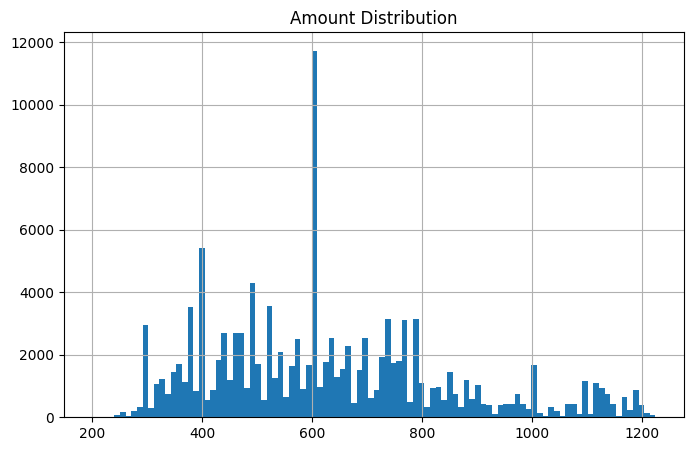

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['Amount'].hist(bins=100)
plt.title("Amount Distribution")
plt.show()

In [46]:
df.to_csv('/Users/omartharwat/Desktop/Eplison/Final_project/cleaned_amazon_sales.csv', index=False)

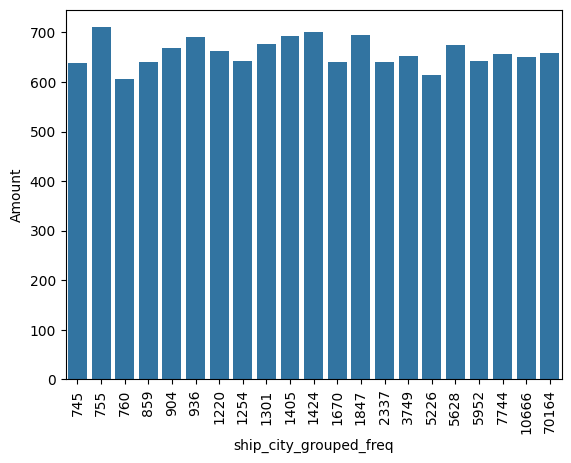

In [87]:
city_amount = df.groupby("ship_city_grouped_freq", as_index=False)["Amount"].mean()
sns.barplot(data=city_amount, x="ship_city_grouped_freq", y="Amount")
plt.xticks(rotation=90)
plt.show()